### Dataset Information
- Name: BriscMat-Brain-Tumour-MRI-Dataset-2026
- Source: Kaggle obtained via https://www.kaggle.com/datasets/vivanrv/briscmat-brain-tumour-mri-dataset-2026

Imported using kagglehub library


### Dataset Description
This dataset contains 2D brain MRI slices for:
- Tumor classification
- Tumor segmentation
- Multi-view analysis

Each sample is stored as an individual `.mat` file.

Tumors are categorized as No Tumor (0), Meningioma (1), Glioma (2), and Pituitary Tumor (3)

MRI Views Code View: Axial (1), Coronal (2), Sagittal (3)


### Dataset Statistics

Dataset splitted into 1000 test samples and 5000 train samples

Test samples distribution:
- Category Distribution: Glioma 254, Meningioma 306, No Tumor 140, Pituitary 300.
- View Distribution: Axial 398, Coronal 305, Sagittal 297.

Train samples distribution:
- Category Distribution: Glioma 1147, Meningioma 1329, No Tumor 1067, Pituitary 1457.
- View Distribution: Axial 1595, Coronal 1676, Sagittal 1729.


### File Content (.mat keys)
Each `.mat` file contains the following keys:
- cjdata.label: Tumor class label (0 → No Tumor, 1 → Meningioma, 2 → Glioma, 3 → Pituitary)
- cjdata.image: Grayscale MRI image (2D NumPy array, typically 0–255)
- cjdata.tumorMask:Binary segmentation mask (1 → Tumor, 0 → Background)
- cjdata.view: View identifier (1 → Axial, 2 → Coronal, 3 → Sagittal)

### Key Characteristics
- Multi-class tumor dataset (4 classes)
- Multi-view MRI images
- Supports:
  - Classification tasks
  - Segmentation tasks
  - Multi-task deep learning
  - View-aware modeling\n

#### Import Libraries and Data Loading via Kaggle Hub dan Aktivasi GPU dengan CUDA

In [1]:
import os
import glob
import random
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

# Aktivasi GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# Import Dataset via Kaggle Hub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivanrv/briscmat-brain-tumour-mri-dataset-2026")

print("Path to dataset files:", path)

Device: cuda


c:\Users\steve\Documents\GitHub\Deep Learning Workspace\deeplearningenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\steve\.cache\kagglehub\datasets\vivanrv\briscmat-brain-tumour-mri-dataset-2026\versions\1


#### Section 1: Data Preparation & Exploratory Data Analysis (EDA)

Berhasil mengekstrak 500 sampel untuk EDA.

[1] Menampilkan Spatial Overlay...


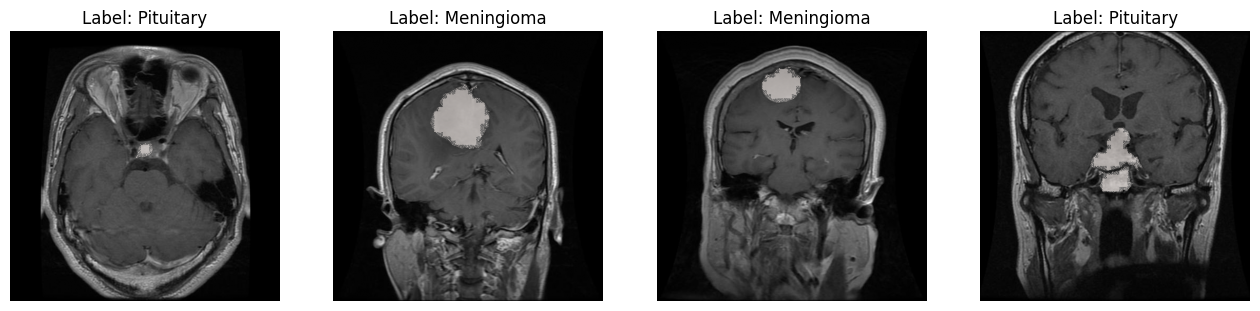

[2] Tabulasi Silang Label vs View:
Label / View    | Axial | Coronal | Sagittal
No Tumor        | 34    | 27      | 33      
Meningioma      | 53    | 49      | 39      
Glioma          | 44    | 39      | 32      
Pituitary       | 49    | 43      | 58      


In [2]:
# Konstanta Label dan View
LABEL_MAP = {0: "No Tumor", 1: "Meningioma", 2: "Glioma", 3: "Pituitary"}
VIEW_MAP = {1: "Axial", 2: "Coronal", 3: "Sagittal"}

# Ambil 500 sampel acak untuk analisis EDA
mat_files = glob.glob(os.path.join(path, '**', '*.mat'), recursive=True)
sampled_files = random.sample(mat_files, min(500, len(mat_files)))

extracted_data = []
for file in sampled_files:
    mat_dict = loadmat(file)
    if 'cjdata.image' in mat_dict:
        img = np.array(mat_dict['cjdata.image']).astype(np.float32)
        mask_data = mat_dict.get('cjdata.tumorMask')
        mask = np.array(mask_data).astype(np.uint8) if mask_data is not None else np.zeros_like(img, dtype=np.uint8)
        lbl = int(np.array(mat_dict.get('cjdata.label', 0)).item())
        view = int(np.array(mat_dict.get('cjdata.view', 1)).item())
        extracted_data.append({'image': img, 'mask': mask, 'label': lbl, 'view': view})

print(f"Berhasil mengekstrak {len(extracted_data)} sampel untuk EDA.\n")

# 1. Plot Spatial Overlay (Gambar MRI + Masker Tumor)
print("[1] Menampilkan Spatial Overlay...")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, data in zip(axes, extracted_data[:4]):
    ax.imshow(data['image'], cmap='gray')
    ax.imshow(np.ma.masked_where(data['mask'] == 0, data['mask']), cmap='Reds', alpha=0.5)
    ax.set_title(f"Label: {LABEL_MAP.get(data['label'])}")
    ax.axis('off')
plt.show()

# 2. Distribusi Tabulasi Label vs View
print("[2] Tabulasi Silang Label vs View:")
cross_tab = np.zeros((4, 3), dtype=int)
for data in extracted_data:
    if 0 <= data['label'] <= 3 and 1 <= data['view'] <= 3:
        cross_tab[data['label']][data['view']-1] += 1

print(f"{'Label / View':<15} | Axial | Coronal | Sagittal")
for lbl_id, name in LABEL_MAP.items():
    counts = cross_tab[lbl_id]
    print(f"{name:<15} | {counts[0]:<5} | {counts[1]:<7} | {counts[2]:<8}")

#### Section 2: Data Preprocessing dengan PyTorch

##### Sub-Section 2.1 Konversi format mat menjadi .pt 

In [3]:
# Konversi format .mat menjadi tensor .pt yang siap pakai untuk training PyTorch
output_dir = "processed"
os.makedirs(os.path.join(output_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "test"), exist_ok=True)

metadata = []
splits = ['train', 'test']

for split in splits:
    split_files = glob.glob(os.path.join(path, f"*{split}*", "**", "*.mat"), recursive=True)
    if not split_files:
         split_files = glob.glob(os.path.join(path, "**", f"*{split}*", "*.mat"), recursive=True)
         
    print(f"Memproses kelompok {split} ({len(split_files)} file)...")
    
    for i, file_path in enumerate(split_files):
        mat_dict = loadmat(file_path)
        if 'cjdata.image' not in mat_dict:
            continue
            
        img_tensor = torch.tensor(np.array(mat_dict['cjdata.image']), dtype=torch.float32)
        mask_data = mat_dict.get('cjdata.tumorMask')
        mask_tensor = torch.tensor(np.array(mask_data) if mask_data is not None else np.zeros_like(img_tensor), dtype=torch.uint8)
        label = int(np.array(mat_dict.get('cjdata.label', 0)).item())
        view = int(np.array(mat_dict.get('cjdata.view', 1)).item())
        
        filename = os.path.basename(file_path).replace('.mat', '.pt')
        target_path = os.path.join(output_dir, split, filename)
        
        # Simpan tensor
        torch.save({'image': img_tensor, 'mask': mask_tensor, 'label': label, 'view': view}, target_path)
        
        # Catat di metadata
        metadata.append({
            'split': split,
            'label': label,
            'view': view,
            'processed_path': f"{split}/{filename}",
            'image_shape': list(img_tensor.shape)
        })

with open(os.path.join(output_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)
    
print(f"Total {len(metadata)} sampel tersimpan di folder './processed/'.")

Memproses kelompok train (5000 file)...
Memproses kelompok test (1000 file)...
Total 6000 sampel tersimpan di folder './processed/'.


##### Sub-Section 2.2: Custom Dataset Class and Sanity Check

In [4]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader

# Custom Dataset Class minimalis untuk Pytorch
class BrainTumorDataset(Dataset):
    def __init__(self, metadata_path='processed/metadata.json', mode='train', base_dir='processed'):
        with open(metadata_path, 'r') as f:
            self.samples = [m for m in json.load(f) if m['split'] == mode]
        self.base_dir = base_dir
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        file_path = os.path.join(self.base_dir, self.samples[idx]['processed_path'])
        data = torch.load(file_path)
        
        # Format image ke (Channel, Height, Width) sesuai standar CNN PyTorch
        image = data['image'].unsqueeze(0)
        
        import torchvision.transforms.functional as TF
        # Standarisasi Ukuran: Resize ke 256x256 agar ukuran batch tidak bertabrakan
        image = TF.resize(image, [256, 256], antialias=True)
        mask = TF.resize(data['mask'].unsqueeze(0), [256, 256], interpolation=TF.InterpolationMode.NEAREST).squeeze(0)
        return image, mask, torch.tensor(data['label'], dtype=torch.long), torch.tensor(data['view'], dtype=torch.long)
        
        

# Test DataLoader
train_dataset = BrainTumorDataset(mode='train')
train_loader = DataLoader(
    train_dataset, 
    batch_size=8, # Sesuaikan agar tidak Out of Memory
    shuffle=True, 
    pin_memory=True, # True jika menggunakan GPU
    num_workers=0
)

images, masks, labels, views = next(iter(train_loader))

print("Sanity Check Dataset Berhasil!")
print(f"Ukuran batch images: {images.shape} (Batch, Channel, Height, Width)")
print(f"Ukuran batch masks : {masks.shape}")
print(f"Label batch        : {labels.tolist()}")

Sanity Check Dataset Berhasil!
Ukuran batch images: torch.Size([8, 1, 256, 256]) (Batch, Channel, Height, Width)
Ukuran batch masks : torch.Size([8, 256, 256])
Label batch        : [1, 0, 1, 2, 1, 1, 3, 1]
